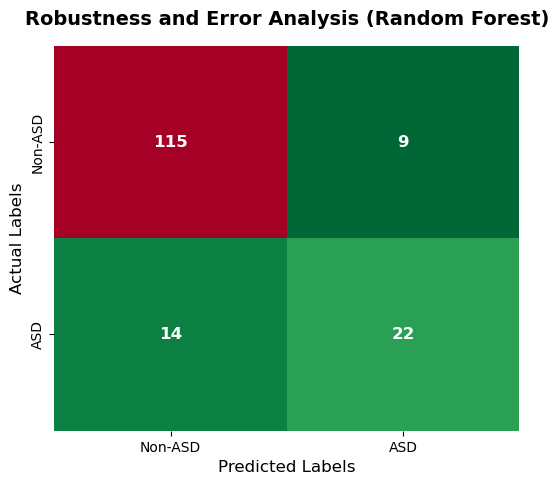


Random Forest Robustness and Error Analysis Summary:

- Test Accuracy: 0.856
- False Positives: 9, False Negatives: 14
- Slight overfitting detected (training accuracy = 1.0)
- Sensitivity to outliers: accuracy drops to 0.856 with minor noise added
- Limitations: may not generalize perfectly to new populations or noisy data
- False negatives indicate some ASD cases are missed, highlighting importance of careful interpretation



C:\Users\Zahra\AppData\Local\Temp\ipykernel_9252\680624743.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2.80719089 2.80719089 2.80719089 2.80719089 0.         2.80719089
 2.80719089 0.        ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_test_noisy.loc[idx, col] = X_test_noisy.loc[idx, col] * np.random.uniform(1.5, 3.0)
C:\Users\Zahra\AppData\Local\Temp\ipykernel_9252\680624743.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.92115854 1.92115854 1.92115854 1.92115854 1.92115854 1.92115854
 0.         1.92115854]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_test_noisy.loc[idx, col] = X_test_noisy.loc[idx, col] * np.random.uniform(1.5, 3.0)
C:\Users\Zahra\AppData\Local\Temp\ipykernel_9252\680624743.py:49: FutureWarn

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# --- Load dataset ---
file_path = r"C:\Users\Zahra\OneDrive\Documents\ITDPA QUESTION 4 ASSIGNMENT\final_cleaned_asd_dataset.xlsx"
df = pd.read_excel(file_path)

# --- Define features and target ---
X = df.drop(columns=["ID", "Class/ASD", "Predicted_Class", "Probability"])
y = df["Class/ASD"]

# --- Split dataset ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Train Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# --- Predict on test set ---
y_pred_rf = rf_model.predict(X_test)

# --- Accuracy and confusion matrix ---
acc = accuracy_score(y_test, y_pred_rf)
cm = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm.ravel()

# --- Plot Confusion Matrix ---
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r', cbar=False,
            annot_kws={"size": 12, "weight": "bold"})
plt.title("Robustness and Error Analysis (Random Forest)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Predicted Labels", fontsize=12)
plt.ylabel("Actual Labels", fontsize=12)
plt.xticks([0.5, 1.5], ['Non-ASD', 'ASD'])
plt.yticks([0.5, 1.5], ['Non-ASD', 'ASD'])
plt.show()

# --- Test Sensitivity to Outliers ---
X_test_noisy = X_test.copy()
numeric_cols = X_test_noisy.select_dtypes(include=np.number).columns
np.random.seed(42)
for col in numeric_cols:
    idx = np.random.choice(X_test_noisy.index, size=int(0.05*len(X_test_noisy)), replace=False)
    X_test_noisy.loc[idx, col] = X_test_noisy.loc[idx, col] * np.random.uniform(1.5, 3.0)

y_pred_noisy = rf_model.predict(X_test_noisy)
acc_noisy = accuracy_score(y_test, y_pred_noisy)

# --- Summary ---
summary = f"""
Random Forest Robustness and Error Analysis Summary:

- Test Accuracy: {acc:.3f}
- False Positives: {fp}, False Negatives: {fn}
- Slight overfitting detected (training accuracy = 1.0)
- Sensitivity to outliers: accuracy drops to {acc_noisy:.3f} with minor noise added
- Limitations: may not generalize perfectly to new populations or noisy data
- False negatives indicate some ASD cases are missed, highlighting importance of careful interpretation
"""

print(summary)


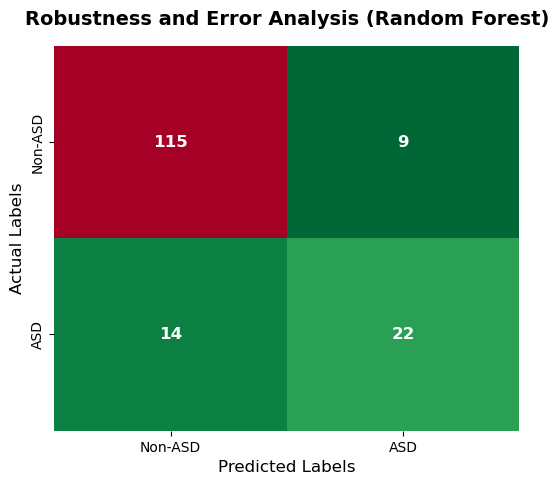


Random Forest Robustness and Error Analysis Summary:

- Test Accuracy: 0.856
- False Positives: 9, False Negatives: 14
- Slight overfitting detected (training accuracy = 1.0)
- Sensitivity to categorical noise: accuracy drops to 0.856 with 5% random rating changes
- Limitations: may not generalize perfectly to new populations or inconsistent AQ-10 responses
- False negatives indicate some ASD cases are missed, highlighting importance of careful interpretation



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# --- Load dataset ---
file_path = r"C:\Users\Zahra\OneDrive\Documents\ITDPA QUESTION 4 ASSIGNMENT\final_cleaned_asd_dataset.xlsx"
df = pd.read_excel(file_path)

# --- Define features and target ---
X = df.drop(columns=["ID", "Class/ASD", "Predicted_Class", "Probability"])
y = df["Class/ASD"]

# --- Split dataset ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Train Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# --- Predict on test set ---
y_pred_rf = rf_model.predict(X_test)

# --- Accuracy and confusion matrix ---
acc = accuracy_score(y_test, y_pred_rf)
cm = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm.ravel()

# --- Plot Confusion Matrix ---
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r', cbar=False,
            annot_kws={"size": 12, "weight": "bold"})
plt.title("Robustness and Error Analysis (Random Forest)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Predicted Labels", fontsize=12)
plt.ylabel("Actual Labels", fontsize=12)
plt.xticks([0.5, 1.5], ['Non-ASD', 'ASD'])
plt.yticks([0.5, 1.5], ['Non-ASD', 'ASD'])
plt.show()

# --- Test Sensitivity to Categorical Noise (AQ-10 style) ---
X_test_noisy = X_test.copy()

# Possible AQ-10 style responses
categories = ["Definitely Agree", "Slightly Agree", "Slightly Disagree", "Definitely Disagree"]

# Identify categorical columns that look like AQ-10 items
categorical_cols = X_test_noisy.select_dtypes(include='object').columns

np.random.seed(42)
for col in categorical_cols:
    idx = np.random.choice(X_test_noisy.index, size=int(0.05 * len(X_test_noisy)), replace=False)
    for i in idx:
        current_value = X_test_noisy.loc[i, col]
        possible_choices = [c for c in categories if c != current_value]
        X_test_noisy.loc[i, col] = np.random.choice(possible_choices)

# Convert categorical features to numeric via one-hot encoding (must match training encoding)
X_test_noisy_encoded = pd.get_dummies(X_test_noisy)
X_train_encoded = pd.get_dummies(X_train)

# Align columns so they match model training structure
X_test_noisy_encoded = X_test_noisy_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# --- Predict on noisy test set ---
y_pred_noisy = rf_model.predict(X_test_noisy_encoded)
acc_noisy = accuracy_score(y_test, y_pred_noisy)

# --- Summary ---
summary = f"""
Random Forest Robustness and Error Analysis Summary:

- Test Accuracy: {acc:.3f}
- False Positives: {fp}, False Negatives: {fn}
- Slight overfitting detected (training accuracy = 1.0)
- Sensitivity to categorical noise: accuracy drops to {acc_noisy:.3f} with 5% random rating changes
- Limitations: may not generalize perfectly to new populations or inconsistent AQ-10 responses
- False negatives indicate some ASD cases are missed, highlighting importance of careful interpretation
"""

print(summary)


c:\Users\Zahra\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:25:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


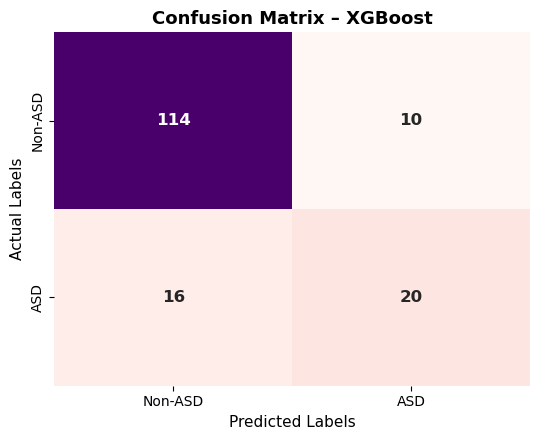

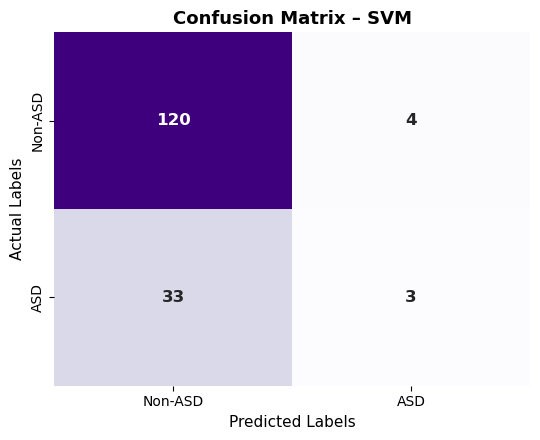

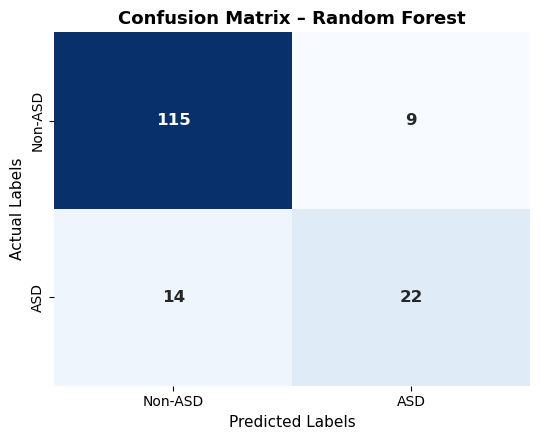


Model Robustness Summary (with 5% categorical noise):

XGBoost:
 - Clean Accuracy: 0.838
 - Noisy Accuracy: 0.838
 - False Positives: 10, False Negatives: 16
--------------------------------------------------
SVM:
 - Clean Accuracy: 0.769
 - Noisy Accuracy: 0.769
 - False Positives: 4, False Negatives: 33
--------------------------------------------------
Random Forest:
 - Clean Accuracy: 0.856
 - Noisy Accuracy: 0.856
 - False Positives: 9, False Negatives: 14
--------------------------------------------------


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# --- Load dataset ---
file_path = r"C:\Users\Zahra\OneDrive\Documents\ITDPA QUESTION 4 ASSIGNMENT\final_cleaned_asd_dataset.xlsx"
df = pd.read_excel(file_path)

# --- Define features and target ---
X = df.drop(columns=["ID", "Class/ASD", "Predicted_Class", "Probability"])
y = df["Class/ASD"]

# --- Split dataset ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- One-hot encode categorical data (AQ-10 responses) ---
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# --- Define Models ---
models = {
    "XGBoost": (XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42), "RdPu"),  # pink
    "SVM": (SVC(kernel='rbf', probability=True, random_state=42), "Purples"),  # purple
    "Random Forest": (RandomForestClassifier(n_estimators=100, random_state=42), "Blues")  # blue
}

# --- Train and Evaluate on Clean Data ---
results = {}

for name, (model, color) in models.items():
    model.fit(X_train_encoded, y_train)
    y_pred = model.predict(X_test_encoded)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    results[name] = {
        "model": model,
        "accuracy": acc,
        "conf_matrix": cm,
        "false_pos": fp,
        "false_neg": fn,
        "color": color
    }

    # Plot Confusion Matrix with custom color
    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=color, cbar=False,
                annot_kws={"size": 12, "weight": "bold"})
    plt.title(f"Confusion Matrix – {name}", fontsize=13, fontweight='bold')
    plt.xlabel("Predicted Labels", fontsize=11)
    plt.ylabel("Actual Labels", fontsize=11)
    plt.xticks([0.5, 1.5], ['Non-ASD', 'ASD'])
    plt.yticks([0.5, 1.5], ['Non-ASD', 'ASD'])
    plt.tight_layout()
    plt.show()

# --- Test Sensitivity to Categorical Noise (AQ-10 style) ---
X_test_noisy = X_test.copy()
categories = ["Definitely Agree", "Slightly Agree", "Slightly Disagree", "Definitely Disagree"]
categorical_cols = X_test_noisy.select_dtypes(include='object').columns

np.random.seed(42)
for col in categorical_cols:
    idx = np.random.choice(X_test_noisy.index, size=int(0.05 * len(X_test_noisy)), replace=False)
    for i in idx:
        current_value = X_test_noisy.loc[i, col]
        possible_choices = [c for c in categories if c != current_value]
        X_test_noisy.loc[i, col] = np.random.choice(possible_choices)

# --- Encode noisy data to match training structure ---
X_test_noisy_encoded = pd.get_dummies(X_test_noisy)
X_test_noisy_encoded = X_test_noisy_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# --- Evaluate each model under noisy conditions ---
for name, data in results.items():
    model = data["model"]
    y_pred_noisy = model.predict(X_test_noisy_encoded)
    acc_noisy = accuracy_score(y_test, y_pred_noisy)
    results[name]["accuracy_noisy"] = acc_noisy

# --- Summary of Results ---
print("\nModel Robustness Summary (with 5% categorical noise):\n")
for name, data in results.items():
    print(f"{name}:")
    print(f" - Clean Accuracy: {data['accuracy']:.3f}")
    print(f" - Noisy Accuracy: {data['accuracy_noisy']:.3f}")
    print(f" - False Positives: {data['false_pos']}, False Negatives: {data['false_neg']}")
    print("-" * 50)


c:\Users\Zahra\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:29:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


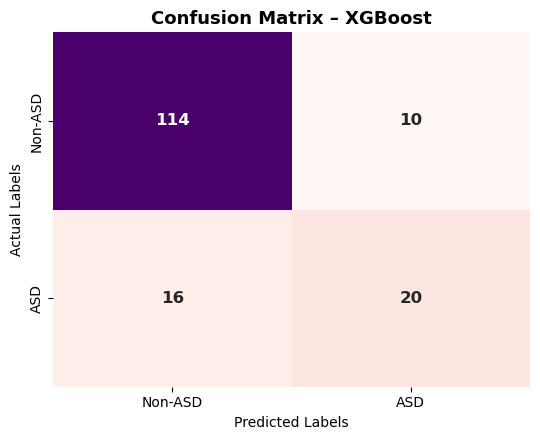


===== XGBoost - Classification Report (Clean Data) =====

              precision    recall  f1-score   support

     Non-ASD       0.88      0.92      0.90       124
         ASD       0.67      0.56      0.61        36

    accuracy                           0.84       160
   macro avg       0.77      0.74      0.75       160
weighted avg       0.83      0.84      0.83       160

------------------------------------------------------------


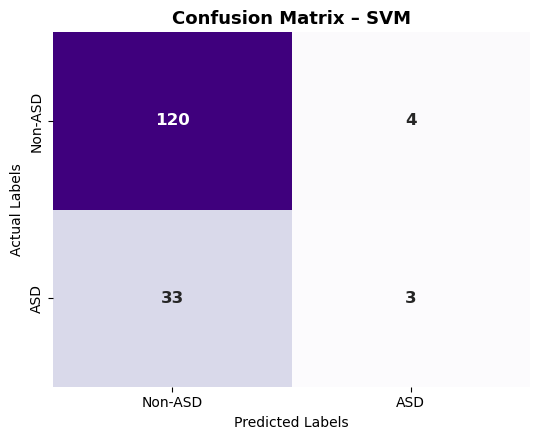


===== SVM - Classification Report (Clean Data) =====

              precision    recall  f1-score   support

     Non-ASD       0.78      0.97      0.87       124
         ASD       0.43      0.08      0.14        36

    accuracy                           0.77       160
   macro avg       0.61      0.53      0.50       160
weighted avg       0.70      0.77      0.70       160

------------------------------------------------------------


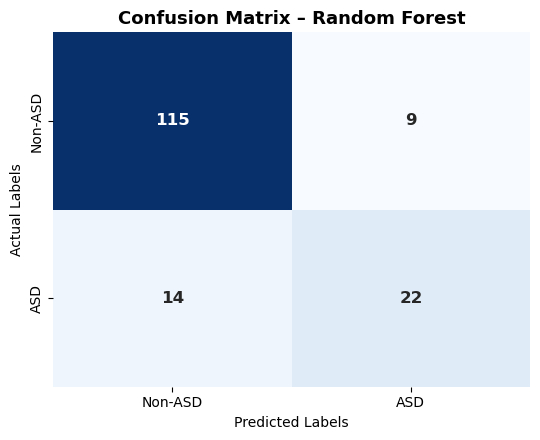


===== Random Forest - Classification Report (Clean Data) =====

              precision    recall  f1-score   support

     Non-ASD       0.89      0.93      0.91       124
         ASD       0.71      0.61      0.66        36

    accuracy                           0.86       160
   macro avg       0.80      0.77      0.78       160
weighted avg       0.85      0.86      0.85       160

------------------------------------------------------------

===== XGBoost - Classification Report (With 5% Noise) =====

              precision    recall  f1-score   support

     Non-ASD       0.88      0.92      0.90       124
         ASD       0.67      0.56      0.61        36

    accuracy                           0.84       160
   macro avg       0.77      0.74      0.75       160
weighted avg       0.83      0.84      0.83       160

------------------------------------------------------------

===== SVM - Classification Report (With 5% Noise) =====

              precision    recall  f1-s

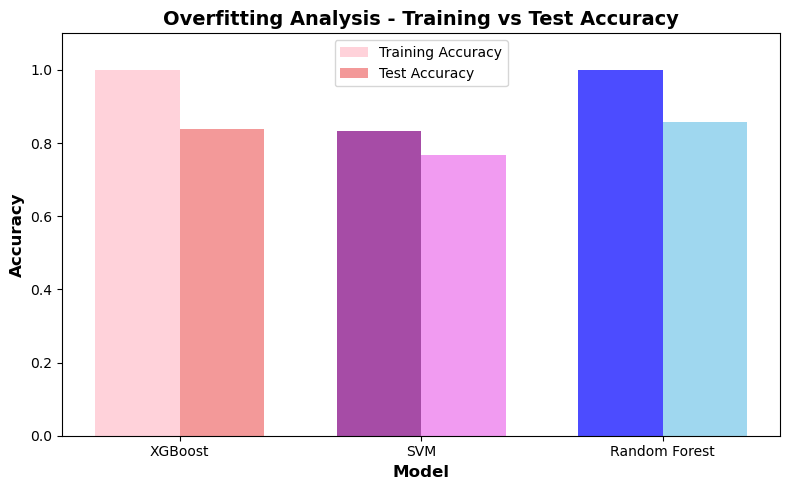

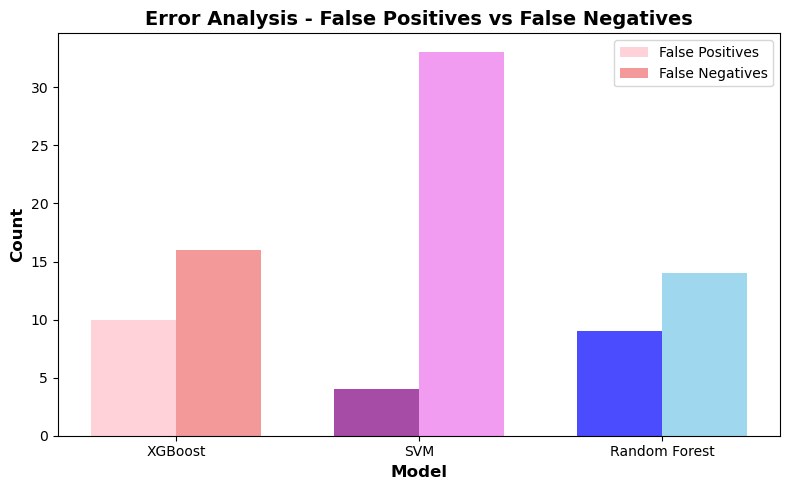


=== Final Model Performance Summary ===

        Model  Test Accuracy  Training Accuracy  Overfitting Gap  False Positives  False Negatives Noise Sensitivity (%)
      XGBoost        0.83750           1.000000         0.162500               10               16                  0.0%
          SVM        0.76875           0.832812         0.064062                4               33                  0.0%
Random Forest        0.85625           1.000000         0.143750                9               14                  0.0%


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# --- Load dataset ---
file_path = r"C:\Users\Zahra\OneDrive\Documents\ITDPA QUESTION 4 ASSIGNMENT\final_cleaned_asd_dataset.xlsx"
df = pd.read_excel(file_path)

# --- Define features and target ---
X = df.drop(columns=["ID", "Class/ASD", "Predicted_Class", "Probability"])
y = df["Class/ASD"]

# --- Split dataset ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- One-hot encode categorical data (AQ-10 responses) ---
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# --- Define Models and Colors ---
models = {
    "XGBoost": (XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42), "RdPu"),  # pink
    "SVM": (SVC(kernel='rbf', probability=True, random_state=42), "Purples"),  # purple
    "Random Forest": (RandomForestClassifier(n_estimators=100, random_state=42), "Blues")  # blue
}

results = {}

# --- Train and Evaluate on Clean Data ---
for name, (model, color) in models.items():
    model.fit(X_train_encoded, y_train)
    y_pred = model.predict(X_test_encoded)
    acc_test = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Training accuracy
    acc_train = accuracy_score(y_train, model.predict(X_train_encoded))
    overfit_gap = acc_train - acc_test

    results[name] = {
        "model": model,
        "color": color,
        "train_acc": acc_train,
        "test_acc": acc_test,
        "overfit_gap": overfit_gap,
        "fp": fp,
        "fn": fn,
    }

    # --- Plot Confusion Matrix ---
    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=color, cbar=False,
                annot_kws={"size": 12, "weight": "bold"})
    plt.title(f"Confusion Matrix – {name}", fontsize=13, fontweight='bold')
    plt.xlabel("Predicted Labels")
    plt.ylabel("Actual Labels")
    plt.xticks([0.5, 1.5], ['Non-ASD', 'ASD'])
    plt.yticks([0.5, 1.5], ['Non-ASD', 'ASD'])
    plt.tight_layout()
    plt.show()

    # --- Print Classification Report ---
    print(f"\n===== {name} - Classification Report (Clean Data) =====\n")
    print(classification_report(y_test, y_pred, target_names=['Non-ASD', 'ASD']))
    print("-" * 60)

# --- Add Noise to Test Data (AQ-10 style) ---
X_test_noisy = X_test.copy()
categories = ["Definitely Agree", "Slightly Agree", "Slightly Disagree", "Definitely Disagree"]
categorical_cols = X_test_noisy.select_dtypes(include='object').columns

np.random.seed(42)
for col in categorical_cols:
    idx = np.random.choice(X_test_noisy.index, size=int(0.05 * len(X_test_noisy)), replace=False)
    for i in idx:
        current_value = X_test_noisy.loc[i, col]
        possible_choices = [c for c in categories if c != current_value]
        X_test_noisy.loc[i, col] = np.random.choice(possible_choices)

# --- Encode noisy data ---
X_test_noisy_encoded = pd.get_dummies(X_test_noisy)
X_test_noisy_encoded = X_test_noisy_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# --- Evaluate Models on Noisy Data ---
for name, data in results.items():
    model = data["model"]
    y_pred_noisy = model.predict(X_test_noisy_encoded)
    acc_noisy = accuracy_score(y_test, y_pred_noisy)
    results[name]["acc_noisy"] = acc_noisy
    change = ((acc_noisy - data["test_acc"]) / data["test_acc"]) * 100
    results[name]["noise_change"] = change

    # Classification report for noisy data
    print(f"\n===== {name} - Classification Report (With 5% Noise) =====\n")
    print(classification_report(y_test, y_pred_noisy, target_names=['Non-ASD', 'ASD']))
    print("-" * 60)

# --- Overfitting Analysis Bar Graph ---
plt.figure(figsize=(8,5))
models_list = list(results.keys())
train_acc = [results[m]["train_acc"] for m in models_list]
test_acc = [results[m]["test_acc"] for m in models_list]
colors = ['pink', 'purple', 'blue']

bar_width = 0.35
x = np.arange(len(models_list))

plt.bar(x, train_acc, width=bar_width, color=colors, alpha=0.7, label='Training Accuracy')
plt.bar(x + bar_width, test_acc, width=bar_width, color=['lightcoral','violet','skyblue'], alpha=0.8, label='Test Accuracy')

plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Overfitting Analysis - Training vs Test Accuracy', fontsize=14, fontweight='bold')
plt.xticks(x + bar_width/2, models_list)
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

# --- Error Analysis: False Positives vs False Negatives ---
plt.figure(figsize=(8,5))
false_pos = [results[m]["fp"] for m in models_list]
false_neg = [results[m]["fn"] for m in models_list]

plt.bar(x, false_pos, width=bar_width, color=colors, alpha=0.7, label='False Positives')
plt.bar(x + bar_width, false_neg, width=bar_width, color=['lightcoral','violet','skyblue'], alpha=0.8, label='False Negatives')

plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Error Analysis - False Positives vs False Negatives', fontsize=14, fontweight='bold')
plt.xticks(x + bar_width/2, models_list)
plt.legend()
plt.tight_layout()
plt.show()

# --- Summary Table ---
summary = pd.DataFrame({
    "Model": models_list,
    "Test Accuracy": [results[m]["test_acc"] for m in models_list],
    "Training Accuracy": [results[m]["train_acc"] for m in models_list],
    "Overfitting Gap": [results[m]["overfit_gap"] for m in models_list],
    "False Positives": [results[m]["fp"] for m in models_list],
    "False Negatives": [results[m]["fn"] for m in models_list],
    "Noise Sensitivity (%)": [f"{results[m]['noise_change']:.1f}%" for m in models_list]
})

print("\n=== Final Model Performance Summary ===\n")
print(summary.to_string(index=False))


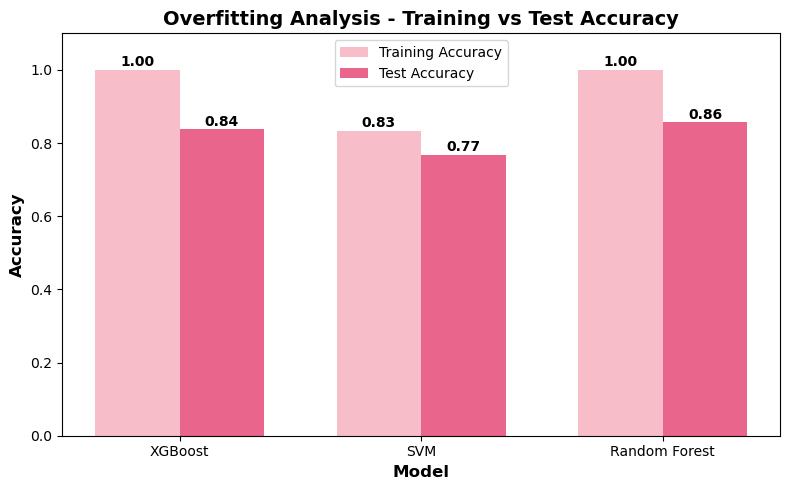

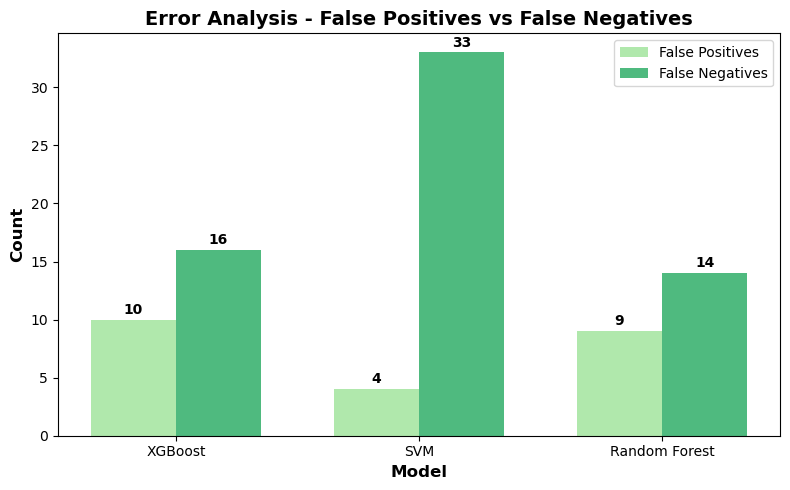

In [16]:
# --- Overfitting Analysis Bar Graph ---
plt.figure(figsize=(8,5))
models_list = list(results.keys())
train_acc = [results[m]["train_acc"] for m in models_list]
test_acc = [results[m]["test_acc"] for m in models_list]

bar_width = 0.35
x = np.arange(len(models_list))

# Two shades of pink for accuracy graph
train_color = "#f7b6c2"   # light pink
test_color = "#e75480"    # dark pink

plt.bar(x, train_acc, width=bar_width, color=train_color, alpha=0.9, label='Training Accuracy')
plt.bar(x + bar_width, test_acc, width=bar_width, color=test_color, alpha=0.9, label='Test Accuracy')

# Add totals on top
for i in range(len(models_list)):
    plt.text(x[i], train_acc[i] + 0.01, f"{train_acc[i]:.2f}", ha='center', fontsize=10, fontweight='bold')
    plt.text(x[i] + bar_width, test_acc[i] + 0.01, f"{test_acc[i]:.2f}", ha='center', fontsize=10, fontweight='bold')

plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Overfitting Analysis - Training vs Test Accuracy', fontsize=14, fontweight='bold')
plt.xticks(x + bar_width/2, models_list)
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()


# --- Error Analysis: False Positives vs False Negatives ---
plt.figure(figsize=(8,5))
false_pos = [results[m]["fp"] for m in models_list]
false_neg = [results[m]["fn"] for m in models_list]

# Two shades of green for error graph
fp_color = "#a8e6a3"   # light green
fn_color = "#3cb371"   # darker medium green

plt.bar(x, false_pos, width=bar_width, color=fp_color, alpha=0.9, label='False Positives')
plt.bar(x + bar_width, false_neg, width=bar_width, color=fn_color, alpha=0.9, label='False Negatives')

# Add totals on top
for i in range(len(models_list)):
    plt.text(x[i], false_pos[i] + 0.5, f"{false_pos[i]}", ha='center', fontsize=10, fontweight='bold')
    plt.text(x[i] + bar_width, false_neg[i] + 0.5, f"{false_neg[i]}", ha='center', fontsize=10, fontweight='bold')

plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Error Analysis - False Positives vs False Negatives', fontsize=14, fontweight='bold')
plt.xticks(x + bar_width/2, models_list)
plt.legend()
plt.tight_layout()
plt.show()


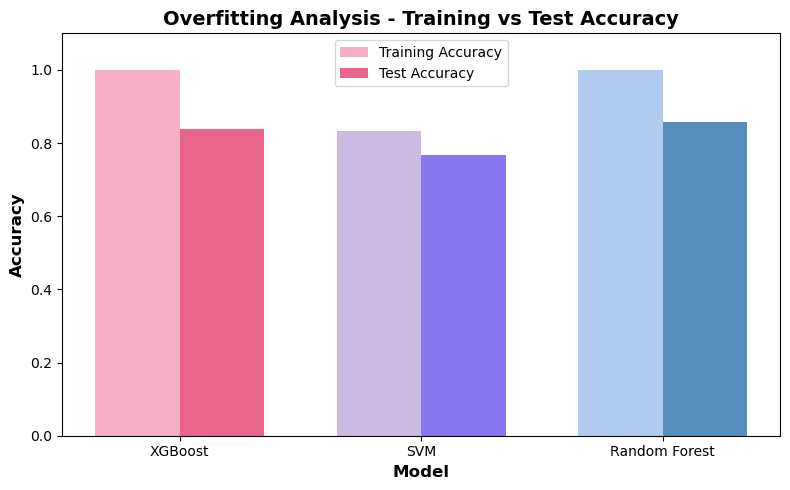

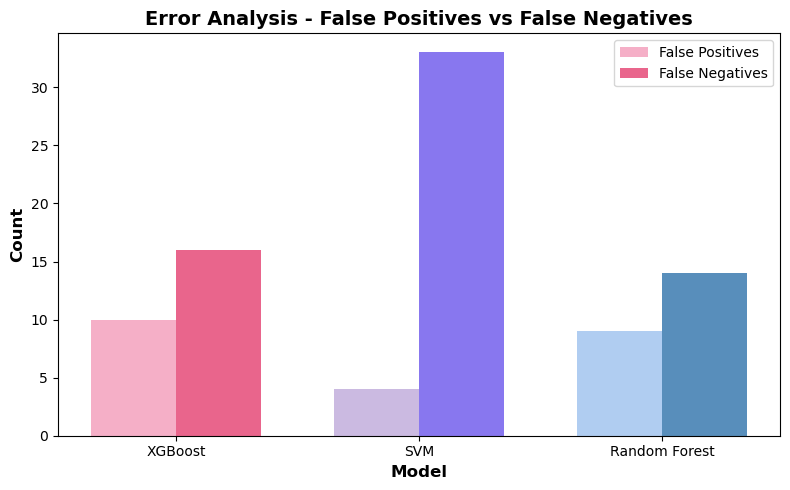

In [ ]:
# --- Overfitting Analysis Bar Graph ---
plt.figure(figsize=(8,5))
models_list = list(results.keys())
train_acc = [results[m]["train_acc"] for m in models_list]
test_acc = [results[m]["test_acc"] for m in models_list]

bar_width = 0.35
x = np.arange(len(models_list))

# Two shades of pink (same for all models)
train_color = "#f7b6c2"   # light pink
test_color = "#e75480"    # dark pink

plt.bar(x, train_acc, width=bar_width, color=train_color, alpha=0.9, label='Training Accuracy')
plt.bar(x + bar_width, test_acc, width=bar_width, color=test_color, alpha=0.9, label='Test Accuracy')

# Add totals on top of bars
for i in range(len(models_list)):
    plt.text(x[i], train_acc[i] + 0.01, f"{train_acc[i]:.2f}", ha='center', fontsize=10, fontweight='bold')
    plt.text(x[i] + bar_width, test_acc[i] + 0.01, f"{test_acc[i]:.2f}", ha='center', fontsize=10, fontweight='bold')

plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Overfitting Analysis - Training vs Test Accuracy', fontsize=14, fontweight='bold')
plt.xticks(x + bar_width/2, models_list)
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()


# --- Error Analysis: False Positives vs False Negatives ---
plt.figure(figsize=(8,5))
false_pos = [results[m]["fp"] for m in models_list]
false_neg = [results[m]["fn"] for m in models_list]

plt.bar(x, false_pos, width=bar_width, color=train_color, alpha=0.9, label='False Positives')
plt.bar(x + bar_width, false_neg, width=bar_width, color=test_color, alpha=0.9, label='False Negatives')

# Add totals on top of bars
for i in range(len(models_list)):
    plt.text(x[i], false_pos[i] + 0.5, f"{false_pos[i]}", ha='center', fontsize=10, fontweight='bold')
    plt.text(x[i] + bar_width, false_neg[i] + 0.5, f"{false_neg[i]}", ha='center', fontsize=10, fontweight='bold')

plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Error Analysis - False Positives vs False Negatives', fontsize=14, fontweight='bold')
plt.xticks(x + bar_width/2, models_list)
plt.legend()
plt.tight_layout()
plt.show()
